# FairKernelPCA

Fair kernel PCA with CKA penalty.

FairKernelPCA extends fair dimensionality reduction to nonlinear manifolds via the kernel trick. It stores centering statistics from training for efficient out-of-sample projection, and supports pre-image reconstruction via kernel ridge regression (Bakir et al. 2004).

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

from fairkl.models import FairKernelPCA
from fairkl.metrics.cka import cka_rbf
from _style import SCATTER_KW, style_ax

## Synthetic Data

Two shifted Gaussian blobs (binary group) in 2D + 3 noise dims.

In [2]:
rng = np.random.default_rng(0)
n = 200
q_raw = rng.choice([-1.0, 1.0], size=n).astype("float32")
q = q_raw.reshape(-1, 1)
group_a = q_raw > 0

X = np.column_stack(
    [
        np.where(group_a, 2.0, -2.0) + rng.standard_normal(n) * 0.8,
        np.where(group_a, 1.5, -1.5) + rng.standard_normal(n) * 0.8,
        rng.standard_normal(n) * 0.5,
        rng.standard_normal(n) * 0.5,
        rng.standard_normal(n) * 0.5,
    ]
).astype("float32")

print(f"n={n}, d={X.shape[1]}")

n=200, d=5


## Standard vs Fair KPCA

In [3]:
kpca_std = FairKernelPCA(n_components=2, sigma=2.0, mu=0.0, sigma_q=0.5)
kpca_std.fit(X, epochs=150, lr=0.02)
Z_std = np.array(kpca_std.transform(X))

kpca_fair = FairKernelPCA(n_components=2, sigma=2.0, mu=100.0, sigma_q=0.5)
kpca_fair.fit(X, q=q, epochs=200, lr=0.01)
Z_fair = np.array(kpca_fair.transform(X))

CKA — standard: 0.7080,  fair: 0.0004


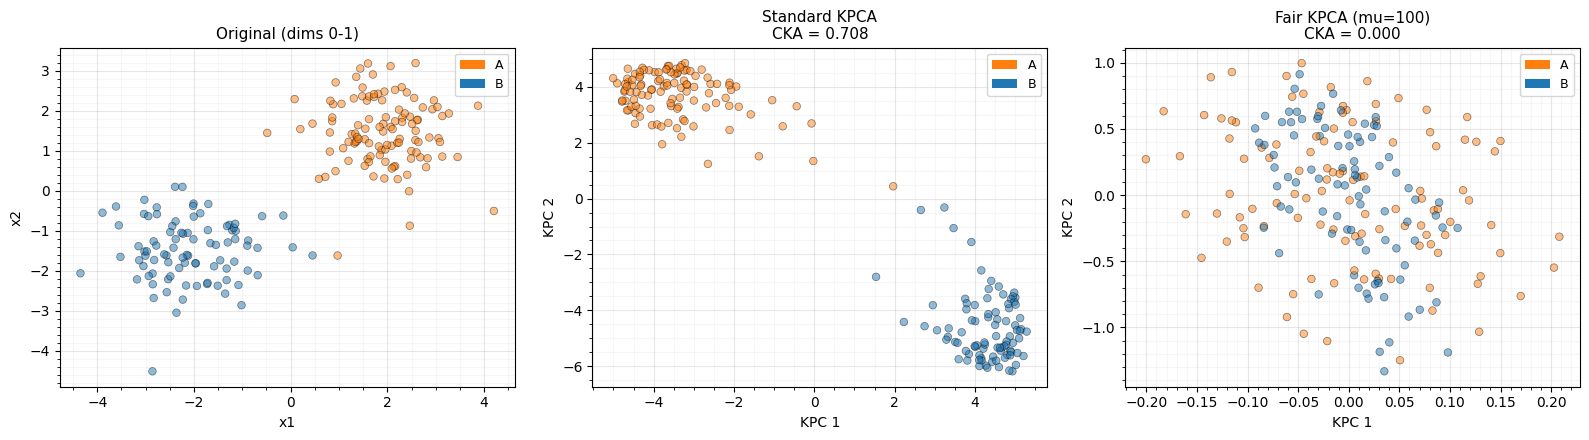

In [4]:
cka_std = float(cka_rbf(Z_std.astype("float32"), q, sigma_q=0.5))
cka_fair = float(cka_rbf(Z_fair.astype("float32"), q, sigma_q=0.5))
print(f"CKA — standard: {cka_std:.4f},  fair: {cka_fair:.4f}")

colors = np.where(group_a, "C1", "C0")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(X[:, 0], X[:, 1], c=colors, **SCATTER_KW)
axes[0].set_title("Original (dims 0-1)", fontsize=11)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
style_ax(axes[0])

axes[1].scatter(Z_std[:, 0], Z_std[:, 1], c=colors, **SCATTER_KW)
axes[1].set_title(f"Standard KPCA\nCKA = {cka_std:.3f}", fontsize=11)
axes[1].set_xlabel("KPC 1")
axes[1].set_ylabel("KPC 2")
style_ax(axes[1])

axes[2].scatter(Z_fair[:, 0], Z_fair[:, 1], c=colors, **SCATTER_KW)
axes[2].set_title(f"Fair KPCA (mu=100)\nCKA = {cka_fair:.3f}", fontsize=11)
axes[2].set_xlabel("KPC 1")
axes[2].set_ylabel("KPC 2")
style_ax(axes[2])

from matplotlib.patches import Patch

for ax in axes:
    ax.legend(
        handles=[Patch(facecolor="C1", label="A"), Patch(facecolor="C0", label="B")],
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## Histograms of KPC 1

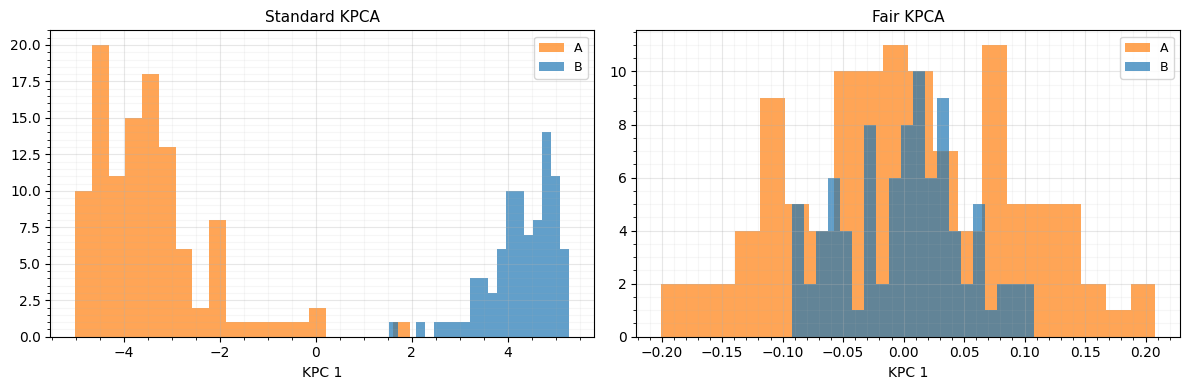

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, title in zip(axes, [Z_std, Z_fair], ["Standard KPCA", "Fair KPCA"]):
    ax.hist(Z[group_a, 0], bins=20, alpha=0.7, color="C1", label="A")
    ax.hist(Z[~group_a, 0], bins=20, alpha=0.7, color="C0", label="B")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("KPC 1")
    ax.legend(fontsize=9)
    style_ax(ax)
plt.tight_layout()
plt.show()

## Reconstruction via Pre-Image

``inverse_transform`` uses kernel ridge regression (Bakir et al. 2004) to map projections back to input space.

> **Why kernel ridge for pre-images?** In kernel PCA there is no
> explicit inverse mapping from the feature space back to input space.
> The pre-image approach fits a kernel ridge regressor from the
> projected coordinates Z back to the original X, using the same RBF
> kernel. This is approximate -- reconstruction error grows with the
> fairness penalty since fair projections discard group-correlated
> variance.

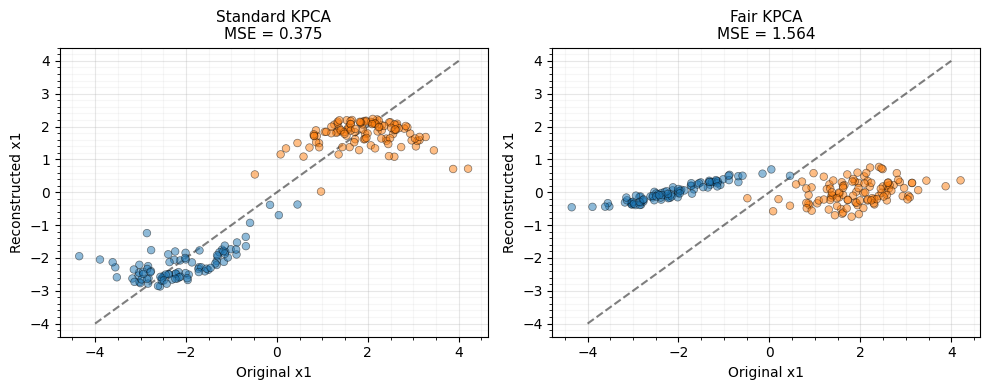

In [6]:
X_hat_std = np.array(kpca_std.inverse_transform(Z_std))
X_hat_fair = np.array(kpca_fair.inverse_transform(Z_fair))

X_c = X - np.mean(X, axis=0, keepdims=True)
recon_std = float(np.mean((X - X_hat_std) ** 2))
recon_fair = float(np.mean((X - X_hat_fair) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X_hat_std[:, 0], c=colors, **SCATTER_KW)
axes[0].plot([-4, 4], [-4, 4], "k--", lw=1.5, alpha=0.5)
axes[0].set_xlabel("Original x1")
axes[0].set_ylabel("Reconstructed x1")
axes[0].set_title(f"Standard KPCA\nMSE = {recon_std:.3f}", fontsize=11)
style_ax(axes[0])

axes[1].scatter(X[:, 0], X_hat_fair[:, 0], c=colors, **SCATTER_KW)
axes[1].plot([-4, 4], [-4, 4], "k--", lw=1.5, alpha=0.5)
axes[1].set_xlabel("Original x1")
axes[1].set_ylabel("Reconstructed x1")
axes[1].set_title(f"Fair KPCA\nMSE = {recon_fair:.3f}", fontsize=11)
style_ax(axes[1])

plt.tight_layout()
plt.show()

## Out-of-sample

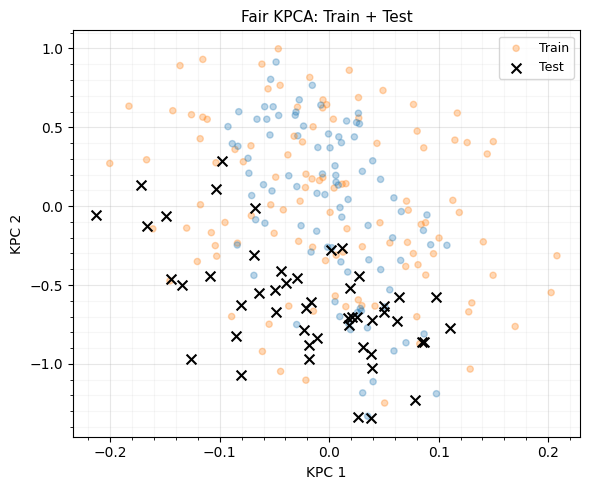

In [7]:
X_test = rng.standard_normal((50, 5)).astype("float32")
Z_test = np.array(kpca_fair.transform(X_test))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    Z_fair[:, 0], Z_fair[:, 1], c=colors, alpha=0.3, s=20, zorder=3, label="Train"
)
ax.scatter(Z_test[:, 0], Z_test[:, 1], c="k", marker="x", s=50, zorder=5, label="Test")
ax.set_xlabel("KPC 1")
ax.set_ylabel("KPC 2")
ax.set_title("Fair KPCA: Train + Test", fontsize=11)
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()